## Understanding Google's Gradient-weighted Class Activation Mapping

Grad-CAM is a visual explanation technique for deep convolution networks (CNNs) that highlights image regions most relevant to a specific prediction. In essence, given a target concept or class (e.g. “cat”), Grad-CAM traces back the gradient of the class score to the final convolutional layer. By pooling those gradients, it assigns an “importance weight” to each feature map (convolutional channel) and combines them to form a coarse heatmap of salient regions. In practice this produces a class-discriminative localization map: hot regions in the image indicate parts that most influence the model’s decision for the chosen class. 

## How Grad-CAM Works 
The intuition behind Grad-CAM is that the gradient of the class score $y^c$ with respect to a feature map $A^k$ tells us how much a small change in $A^k$ would affect the score for class $c$. Gradients flowing back into the last convolutional layer indicate which neurons and spatial locations most influence the decision.
### Steps 
### 1. **Forward Pass**: <br>
Input the image into the CNN and compute the score (logit) $y^c^ for the target class $c$. Record the feature maps $A^k$ from the last convolutional layer.
### 2. **Backward Pass**: <br>
Compute the partial derivaties/gradients $\frac{\partial y^c}{\partial A^k_{ij}}$ for each spatial location $(i,j)$ and feature channel $k$. In practice this is done by backpropagating the gradient of the score for class $c$ while zeroing out all other classes​.
### 3. **Channel Weighting**: <br>
Compute a weight $\alpha_k^c$ for each feature map by global-average-pooling the gradients over the spatial dimensions:
$$\alpha_k^c = \frac{1}{Z} \sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$$
where $Z$ is the number of pixels ($Z = u\times v$ for a feature map of size $u\times v$)​. Intuitively, $\alpha_k^c$ is the importance of feature map $k$ for class $c$: if increasing $A^k_{ij}$ tends to increase $y^c$, then $\alpha_k^c$ will be large.<br>
### 4. **Weighted Combination**: <br>
Form a raw class activation map by a linear combination of the forward feature maps, using the weights $\alpha_k^c$:
$$L^c_{Grad-CAM} = ReLU\left(\sum_k \alpha_k^c A^k\right)$$
whereThe sum $\sum_k \alpha_k^c A^k$ is computed elementwise over each pixel; then a ReLU is applied to keep only positive influences (since negative values would decrease the class score)​. This ensures the heatmap highlights only features that positively support class $c$.
### 5. **Heatmap**<br>
 The resulting map $L^c_{\text{Grad-CAM}}$ is a coarse heatmap at the same spatial resolution as the feature maps (e.g. $14\times14$ for VGG/AlexNet conv layers)​. Finally, upsample $L^c_{\text{Grad-CAM}}$ (e.g. via bilinear interpolation) to the original image size​ and overlay it on the image. Areas with higher values (often shown in red) indicate regions most important for the network’s prediction of class $c$​

## Code Demonstration

In [2]:
import numpy as np 
from PIL import Image 
import matplotlib as plt 
import cv2 

import torch 
import torch.nn.functional as F 

from torchvision import models 
from torchvision import transforms 


In [3]:
img =  Image.open('photos/cat_dog.webp')
img.size


(640, 480)

In [4]:
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std  = [0.229, 0.244, 0.225])    
                               ])

input_tensor = preprocess(img).unsqueeze(0)
input_tensor.shape


torch.Size([1, 3, 224, 224])

## Loading any Pretrained Model


In [16]:
weights = models.ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=weights)
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Learn about Hooks :
[hooks in pytorch](https://www.youtube.com/watch?v=syLFCVYua6Q)

In [17]:
class GradCAM:
    def __init__(self, model, target_layer)-> None:
        self.model = model
        self.target_layer = target_layer
        self.activation_maps = None 
        self.gradient_maps = None 
        self.hook()
    
    def hook(self):
        def forward_hook(module, in_activation_maps, out_activation_maps):
            self.activation_maps = out_activation_maps
        
        def backward_hook(module, grad_in, grad_out):
            self.gradient_maps = grad_out[0]
        
        target_layer_module = dict(self.model.named_modules())[self.target_layer]
        target_layer_module.register_forward_hook(forward_hook)
        target_layer_module.register_full_backward_hook(backward_hook)
        
    def generate_cam(self, input_tensor):
        output = self.model(input_tensor)
        class_idx = torch.argmax(output,dim=1)
        
        self.model.zero_grad()
        
        target_class = output[:, class_idx]
        print(target_class)
        target_class.backward()
        
        weights = torch.mean(self.gradient_maps, dim=(2,3))
        cam     = torch.zeros(self.activation_maps.shape[2:], dtype = torch.float32)

        for i,w in enumerate(weights[0]):
            cam+= w * self.activation_maps[0,i,:,:]
        
        cam =F.relu(cam)
        
        return (cam-cam.min())/(cam.max()-cam.min())
    

In [18]:
grad_cam = GradCAM(resnet_model,'layer4')
cam = grad_cam.generate_cam(input_tensor)


tensor([[16.4370]], grad_fn=<IndexBackward0>)


In [22]:
original_img = np.array(img)
if original_img.ndim == 2:
    original_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)
else:
    original_img = cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR)
orginal_img = np.float32(original_img) / 255

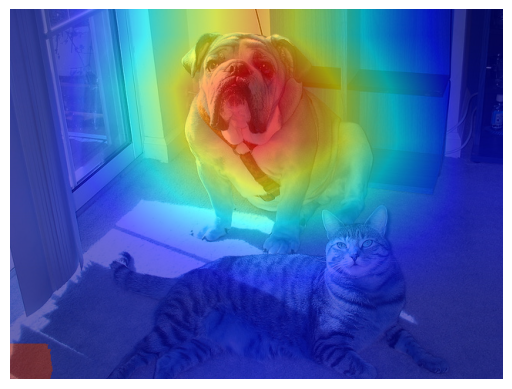

In [28]:
import matplotlib.pyplot as plt
import numpy as np

if type(cam) == torch.Tensor:
    cam = cam.detach().numpy

cam = cv2.resize(cam, (orginal_img.shape[1], orginal_img.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(cam * 255), cv2.COLORMAP_JET)
overlay = heatmap/175 + orginal_img
overlay = overlay / np.max(overlay)
plt.imshow(overlay)
plt.axis('off')
plt.show()